# **Практическая работа №9. Пространственный анализ доступности социальной инфраструктуры с использованием OpenStreetMap**

## **Цель работы**

Овладеть методами пространственного анализа городских территорий на основе открытых геоданных: загрузка данных из OpenStreetMap, конструирование пространственных признаков и их визуализация на тепловых картах административных районов и гексагональной H3‑сетки.

## **Введение**

Доступность социальной инфраструктуры (школы, детские сады, поликлиники, общественный транспорт и т.п.) является базовой характеристикой качества городской среды. Современные методы геоанализа позволяют количественно оценивать уровень такой доступности для разных участков города и визуализировать результаты в удобной для интерпретации форме.

В данной практической работе вы выполните полный цикл пространственного анализа: от выбора территории и постановки исследовательской задачи до расчёта интегрального показателя доступности и построения тепловых карт по районам и гексагональной ячейке.

## **Задание**

Провести пространственное исследование уровня доступности социальной инфраструктуры для жителей выбранной городской территории, используя данные OpenStreetMap, и визуализировать результаты:

- на карте административных районов;
- на гексагональной H3‑сетке.

---

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и постановка задачи**

1. **Выбор территории и фокуса исследования**

   - Выберите город и область интереса (ROI) для анализа:
     - это может быть весь город или его часть (например, центральные районы, спальный район, новая застройка).
   - Определите фокус исследования:
     - например:
       - доступность школ и детских садов;
       - доступность поликлиник и больниц;
       - комплексная доступность нескольких типов объектов (школы + сады + поликлиники + остановки ОТ).
   - Кратко обоснуйте выбор:
     - почему вы выбрали именно эту территорию;
     - почему выбранный фокус социальной инфраструктуры важен и интересен для анализа.

### **Выбор территории и фокуса исследования**

> В качестве территории исследования выбран город Ростов-на-Дону.
> Фокус исследования — доступность этнокультурной и общественной инфраструктуры, включающей дома культуры, музеи, библиотеки, театры, и парки. Выбор города обусловлен его сформировавшейся городской средой и наличием объектов культурного и общественного назначения, играющих важную роль в организации досуга населения.
> Объекты этнокультурной и общественной инфраструктуры существенно влияют на качество городской среды и возможности культурного развития жителей, что делает анализ их пространственной доступности актуальной задачей.


2. **Определение признаков доступности**

   - Сформулируйте **не менее 5 признаков**, которые, по вашему мнению, характеризуют доступность социальной инфраструктуры для жителей. Примеры признаков:
     - количество объектов нужного типа в шаговой доступности;
     - средняя удалённость до ближайшего объекта;
     - наличие альтернативных видов инфраструктуры (например, частные и государственные школы);
     - транспортная доступность (наличие остановок общественного транспорта поблизости);
     - обеспеченность зелёными зонами рядом с социальной инфраструктурой (парки возле школ и т.п.).
   - Для каждого признака определите, **какими тегами OpenStreetMap** его можно описать. Примеры тегов:
     - `amenity=school`, `amenity=kindergarten`, `amenity=clinic`, `amenity=hospital`;
     - `highway=bus_stop`, `railway=subway_entrance`;
     - `leisure=park`, `leisure=pitch`;
     - границы районов: `boundary=administrative`, `admin_level=*`.
   - Составьте **таблицу соответствия**:

     | признак                     | Описание признака                             | OSM‑теги / атрибуты                       |
     |----------------------------|----------------------------------------------|-------------------------------------------|
     | Кол-во школ в шаговой доступности | Школы в радиусе 800 м от ячейки/района | `amenity=school`                          |
     | Наличие детских садов      | Детсады в радиусе 600 м                     | `amenity=kindergarten`                    |
     | Транспортная доступность   | Остановки ОТ в радиусе 400 м                | `highway=bus_stop`, `railway=tram_stop`   |
     | Близость метро             | Минимальное расстояние до метро             | `railway=subway_entrance`                 |
     | Наличие зелёных зон        | Площадь парков в радиусе 800 м              | `leisure=park`                            |


### **Признаки доступности этнокультурной и общественной инфраструктуры**

| Признак                                         | Описание признака                                                                  | OSM-теги / атрибуты                     |
| ----------------------------------------------- | ---------------------------------------------------------------------------------- | --------------------------------------- |
| Количество домов культуры в шаговой доступности | Число домов культуры и общественных центров в радиусе **800 м** от ячейки / района | `amenity=community_centre`              |
| Количество музеев в шаговой доступности         | Число музеев в радиусе **800 м**                                                   | `tourism=museum`                        |
| Количество библиотек в шаговой доступности      | Число библиотек в радиусе **800 м**                                                | `amenity=library`                       |
| Количество театров в зоне доступности           | Число театров в радиусе **1200 м**                                                 | `amenity=theatre`                       |
| Доступность парков                              | Суммарная площадь парков в радиусе **800 м**                                       | `leisure=park`                          |


3. **Сбор исходных данных из OpenStreetMap**

   - Настройте необходимые библиотеки (по аналогии с примером):  
     `osmnx`, `geopandas`, `h3`, `h3pandas`, `leafmap`, `shapely`, `pandas`, `numpy` и др.
   - С помощью интерактивной карты (`leafmap.Map` и инструмент рисования) определите **bounding box** или полигон области интереса.
   - Загрузите из OSM с помощью `osmnx.features_from_bbox()` (или аналогичных функций):
     - объекты социальной инфраструктуры, соответствующие вашим признакам;
     - слои, отражающие административные границы районов (или муниципальных округов).

   - Приведите все пространственные слои к единой системе координат (например, `EPSG:3857` для метрических расчётов).

In [ ]:
%%capture
!pip install scikit-learn geopandas h3pandas h3~=3.0 leafmap mapclassify matplotlib seaborn streamlit osmnx openrouteservice polyline -q

In [ ]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np

import leafmap
from shapely.geometry import Polygon

import h3
import geopandas as gpd
from shapely.geometry import Polygon, mapping

import matplotlib.pyplot as plt
import seaborn as sns

---

In [ ]:
PLACE_NAME = "Ростов-на-Дону"

city_boundary = ox.geocode_to_gdf(PLACE_NAME)
print(type(city_boundary))

city_boundary

<class 'geopandas.geodataframe.GeoDataFrame'>


,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((39.47099 47.20487, 39.48586 47.17578...",39.470991,47.153377,39.85139,47.355573,189363748,relation,1285772,47.22226,39.719874,place,city,16,0.674872,city,Rostov-on-Don,"Rostov-on-Don, Rostov Oblast, Southern Federal..."


In [ ]:
map = leafmap.Map(center=[47.222109, 39.718813], zoom=11)

map.add_gdf(
    city_boundary,
    layer_name=f"Граница г. {PLACE_NAME}",
    style={
        "color": "red",
        "fillColor": "red",
        "weight": 3,
    },
)

map.add_layer_control()

map

Map(center=[47.222109, 39.718813], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title',…

In [ ]:
cultural_tags = {
    "amenity": [
        "community_centre",
        "library",
        "theatre",
        "place_of_worship"
    ],
    "tourism": ["museum"],
    "leisure": ["park"]
}

In [ ]:
city_polygon = city_boundary.geometry.iloc[0]

type(city_polygon)

shapely.geometry.polygon.Polygon

In [ ]:
cultural_objects = ox.features_from_polygon(
    polygon=city_polygon,
    tags=cultural_tags
)

print("Кол-во культурных объектов:", len(cultural_objects))

cultural_objects.head()

Кол-во культурных объектов: 382


geometry  \
element id                                     
node    295390885  POINT (39.63715 47.19053)   
        557179516  POINT (39.70358 47.25891)   
        598835296   POINT (39.63903 47.2085)   
        667395626  POINT (39.71238 47.22414)   
        667397866    POINT (39.718 47.22325)   

                                                            alt_name   museum  \
element id                                                                      
node    295390885  Ростовский музей железнодорожного транспорта Р...  railway   
        557179516                                                NaN      NaN   
        598835296                                                NaN      NaN   
        667395626                                                NaN      NaN   
        667397866                                                NaN      NaN   

                                           name          name:en     name:ru  \
element id                                                                     
node    295390885                      Музей ЖД  Railroad Museum  Музей СКЖД   
        557179516   Римско-католическая церковь              NaN         NaN   
        598835296  Городская детская библиотека              NaN         NaN   
        667395626       Библиотека ЮРИФ РАНХиГС              NaN         NaN   
        667397866        Библиотека РГЭУ "РИНХ"              NaN         NaN   

                                                       official_name  \
element id                                                             
node    295390885           Ростовский музей железнодорожной техники   
        557179516                                                NaN   
        598835296  Главная городская детская библиотека им. В.И. ...   
        667395626                                                NaN   
        667397866                                                NaN   

                       opening_hours             phone tourism  ... name:be  \
element id                                                      ...           
node    295390885  Tu-Su 10:00-17:00  +7 863 238 32 93  museum  ...     NaN   
        557179516                NaN               NaN     NaN  ...     NaN   
        598835296                NaN               NaN     NaN  ...     NaN   
        667395626                NaN         299-92-39     NaN  ...     NaN   
        667397866                NaN               NaN     NaN  ...     NaN   

                  name:fr name:ka theatre:type type addr:housenumber2  \
element id                                                              
node    295390885     NaN     NaN          NaN  NaN               NaN   
        557179516     NaN     NaN          NaN  NaN               NaN   
        598835296     NaN     NaN          NaN  NaN               NaN   
        667395626     NaN     NaN          NaN  NaN               NaN   
        667397866     NaN     NaN          NaN  NaN               NaN   

                  addr:street2 wheelchair:description  fee  fax  
element id                                                       
node    295390885          NaN                    NaN  NaN  NaN  
        557179516          NaN                    NaN  NaN  NaN  
        598835296          NaN                    NaN  NaN  NaN  
        667395626          NaN                    NaN  NaN  NaN  
        667397866          NaN                    NaN  NaN  NaN  

[5 rows x 84 columns]

In [ ]:
map.add_gdf(
    cultural_objects,
    layer_name="Культурные объекты",
    style={
        "color": "blue",
        "weight": 2,
    },
)

map

Map(bottom=184231.0, center=[47.222109, 39.718813], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [ ]:
admin_tags = {
    "boundary": "administrative"
}

In [ ]:
administrative_units = ox.features_from_polygon(
    polygon=city_polygon,
    tags=admin_tags
)

city_districts = administrative_units[
    administrative_units["admin_level"] == "9"
].copy()

city_districts = city_districts[
    city_districts["name"]
    .fillna("")
    .str.contains("район", case=False)
]

city_districts

geometry  \
element  id                                                           
relation 2227024  POLYGON ((39.41415 47.23012, 39.41475 47.23014...   
         2227607  POLYGON ((39.5446 47.16647, 39.54504 47.17204,...   
         2227685  POLYGON ((39.65356 47.2467, 39.65444 47.24662,...   
         2228342  POLYGON ((39.6157 47.25561, 39.62062 47.25988,...   
         2228364  POLYGON ((39.71253 47.24456, 39.71759 47.24441...   
         2228370  POLYGON ((39.73283 47.24392, 39.73909 47.24372...   
         2228519  POLYGON ((39.68348 47.29163, 39.68364 47.29174...   
         2228520  POLYGON ((39.72691 47.28961, 39.72758 47.28944...   

                        boundary  ref admin_level source boat  \
element  id                                                     
relation 2227024  administrative  NaN           9    NaN  NaN   
         2227607  administrative  NaN           9    NaN  NaN   
         2227685  administrative  NaN           9    NaN  NaN   
         2228342  administrative  NaN           9    NaN  NaN   
         2228364  administrative  NaN           9    NaN  NaN   
         2228370  administrative  NaN           9    NaN  NaN   
         2228519  administrative  NaN           9    NaN  NaN   
         2228520  administrative  NaN           9    NaN  NaN   

                                   name               name:uk waterway  \
element  id                                                              
relation 2227024        Советский район      Радянський район      NaN   
         2227607  Железнодорожный район     Залізничний район      NaN   
         2227685        Ленинский район      Ленінський район      NaN   
         2228342      Октябрьский район       Жовтневий район      NaN   
         2228364        Кировский район      Кіровський район      NaN   
         2228370     Пролетарский район   Пролетарський район      NaN   
         2228519    Ворошиловский район  Ворошиловський район      NaN   
         2228520     Первомайский район  Першотравневий район      NaN   

                 alt_name  ... name:ko name:mk name:ru:word_stress old_name  \
element  id                ...                                                
relation 2227024      NaN  ...     NaN     NaN                 NaN      NaN   
         2227607      NaN  ...     NaN     NaN                 NaN      NaN   
         2227685      NaN  ...     NaN     NaN                 NaN      NaN   
         2228342      NaN  ...     NaN     NaN                 NaN      NaN   
         2228364      NaN  ...     NaN     NaN                 NaN      NaN   
         2228370      NaN  ...     NaN     NaN                 NaN      NaN   
         2228519      NaN  ...     NaN     NaN                 NaN      NaN   
         2228520      NaN  ...     NaN     NaN                 NaN      NaN   

                 short_name short_name:be short_name:ru short_name:uk sqkm  \
element  id                                                                  
relation 2227024        NaN           NaN           NaN           NaN  NaN   
         2227607        NaN           NaN           NaN           NaN  NaN   
         2227685        NaN           NaN           NaN           NaN  NaN   
         2228342        NaN           NaN           NaN           NaN  NaN   
         2228364        NaN           NaN           NaN           NaN  NaN   
         2228370        NaN           NaN           NaN           NaN  NaN   
         2228519        NaN           NaN           NaN           NaN  NaN   
         2228520        NaN           NaN           NaN           NaN  NaN   

                 start_date  
element  id                  
relation 2227024        NaN  
         2227607        NaN  
         2227685        NaN  
         2228342        NaN  
         2228364        NaN  
         2228370        NaN  
         2228519        NaN  
         2228520        NaN  

[8 rows x 94 columns]

In [ ]:
city_polygon_from_districts = city_districts.unary_union

city_boundary = gpd.GeoDataFrame(
    {"name": [city_boundary.name]},
    geometry=[city_polygon_from_districts],
    crs="EPSG:4326",
)

In [ ]:
map = leafmap.Map(center=[47.222109, 39.718813], zoom=11)

map.add_gdf(
    city_districts,
    layer_name="Районы города",
    style={
        "color": "green",
        "fillColor": "green",
        "weight": 3,
        "fillOpacity": 0.2,
    },
)

map.add_layer_control()

map

Map(center=[47.222109, 39.718813], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title',…

In [ ]:
city_boundary = city_boundary.to_crs(epsg=3857)
city_districts = city_districts.to_crs(epsg=3857)
cultural_objects = cultural_objects.to_crs(epsg=3857)

### **Часть 2. Пространственное агрегирование и инженерия признаков**

1. **Построение гексагональной H3‑сетки**

   - Определите подходящее **разрешение (resolution)** H3‑сетки для вашей территории:
     - маленькое значение (5–7) — крупные ячейки для больших территорий;
     - большое значение (8–10 и выше) — более детальный анализ на уровне кварталов/микрорайонов.
   - Обоснуйте ваш выбор resolution с точки зрения:
     - размера города или ROI;
     - характера объектов (шаговая доступность, плотность застройки);
     - удобства визуализации и интерпретации.
   - Сгенерируйте H3‑индексы, покрывающие выбранный полигон (через `h3.polyfill_geojson`), и создайте `GeoDataFrame` с геометриями ячеек.

In [ ]:
H3_RESOLUTION = 8

city_polygon_wgs84 = city_boundary.to_crs(epsg=4326).geometry.iloc[0]
city_geojson = mapping(city_polygon_wgs84)

h3_indexes = list(
    h3.polyfill_geojson(
        city_geojson,
        H3_RESOLUTION
    )
)

print("Количество H3 ячеек:", len(h3_indexes))


Количество H3 ячеек: 497


In [ ]:
def h3_to_polygon(h3_index: str) -> Polygon:
    """
    Convert H3 index to shapely polygon.

    :param h3_index: H3 cell index

    :return: Polygon geometry of H3 cell
    """
    boundary = h3.h3_to_geo_boundary(h3_index, geo_json=True)
    return Polygon(boundary)

In [ ]:
h3_gdf = gpd.GeoDataFrame(
    {"h3_index": h3_indexes},
    geometry=[h3_to_polygon(h) for h in h3_indexes],
    crs="EPSG:4326",
)

h3_gdf.head()


,h3_index,geometry
0,882d440c3dfffff,"POLYGON ((39.71928 47.17558, 39.72283 47.17139..."
1,882d44011bfffff,"POLYGON ((39.50857 47.17752, 39.51214 47.17333..."
2,882d440f55fffff,"POLYGON ((39.61943 47.16609, 39.62299 47.1619,..."
3,882d443a55fffff,"POLYGON ((39.75119 47.34509, 39.75475 47.3409,..."
4,882d440e4dfffff,"POLYGON ((39.58696 47.21222, 39.59052 47.20804..."


In [ ]:
map = leafmap.Map(center=[47.222109, 39.718813], zoom=11)

map.add_gdf(
    city_boundary,
    layer_name=f"Граница г. {PLACE_NAME}",
    style={
        "color": "red",
        "fillColor": "red",
        "weight": 3,
    },
)

map.add_gdf(
    h3_gdf,
    layer_name="H3 сетка",
    style={
        "color": "blue",
        "weight": 1,
        "fillOpacity": 0.05,
    },
)

map.add_layer_control()
map


Map(center=[47.222109, 39.718813], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title',…

> Для города Ростов-на-Дону выбрано разрешение H3-сетки 8, поскольку оно обеспечивает достаточно детальную пространственную разбивку территории на уровне городских микрорайонов. Размер ячеек при данном разрешении сопоставим с радиусами шаговой доступности объектов культурной и общественной инфраструктуры, которые в рамках исследования составляют от 400 до 1200 метров. Это позволяет корректно учитывать доступность парков, библиотек, музеев и домов культуры для жителей.
> Использование меньшего разрешения привело бы к формированию слишком крупных ячеек, внутри которых объединялись бы разнородные городские зоны, что снизило бы точность анализа. Более высокое разрешение, напротив, существенно увеличило бы количество ячеек и усложнило бы расчёты и визуализацию результатов.




2. **Агрегирование по административным районам**

   - Подготовьте слой районов (например, `admin_level=8`):
     - при необходимости отфильтруйте только нужный уровень административного деления.
   - Для каждого района рассчитайте показатели, связанные с выбранными типами инфраструктуры. Примеры:
     - количество школ/детсадов/поликлиник внутри района;
     - плотность объектов (количество на км²);
     - суммарная площадь парков;
     - количество остановок ОТ.
   - Добавьте эти признаки в таблицу районов.

In [ ]:
city_districts = city_districts.reset_index(drop=True)
city_districts["district_id"] = city_districts.index

city_districts.head()

,geometry,boundary,ref,admin_level,source,boat,name,name:uk,waterway,alt_name,...,name:mk,name:ru:word_stress,old_name,short_name,short_name:be,short_name:ru,short_name:uk,sqkm,start_date,district_id
0,"POLYGON ((4387562.974 5979717.212, 4387629.532...",administrative,NaN,9,NaN,NaN,Советский район,Радянський район,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,"POLYGON ((4402085.203 5969289.194, 4402133.794...",administrative,NaN,9,NaN,NaN,Железнодорожный район,Залізничний район,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,"POLYGON ((4414214.553 5982435.054, 4414312.002...",administrative,NaN,9,NaN,NaN,Ленинский район,Ленінський район,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,"POLYGON ((4409999.685 5983895.98, 4410547.677 ...",administrative,NaN,9,NaN,NaN,Октябрьский район,Жовтневий район,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,"POLYGON ((4420778.217 5982084.299, 4421342.306...",administrative,NaN,9,NaN,NaN,Кировский район,Кіровський район,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4


In [ ]:
community_centres = cultural_objects[
    cultural_objects["amenity"] == "community_centre"
]

libraries = cultural_objects[
    cultural_objects["amenity"] == "library"
]

theatres = cultural_objects[
    cultural_objects["amenity"] == "theatre"
]

museums = cultural_objects[
    cultural_objects["tourism"] == "museum"
]

parks = cultural_objects[
    cultural_objects["leisure"] == "park"
]

In [ ]:
def count_objects_within_districts(
    districts: gpd.GeoDataFrame,
    objects: gpd.GeoDataFrame
) -> pd.Series:
    """
    Count objects located inside each district.

    :param districts: GeoDataFrame with district geometries
    :param objects: GeoDataFrame with objects geometries

    :return: Series with counts per district_id
    """
    joined = gpd.sjoin(
        objects,
        districts[["district_id", "geometry"]],
        how="inner",
        predicate="within",
    )

    return joined.groupby("district_id").size()


In [ ]:
city_districts["community_centres_count"] = count_objects_within_districts(
    city_districts, community_centres
)

city_districts["libraries_count"] = count_objects_within_districts(
    city_districts, libraries
)

city_districts["theatres_count"] = count_objects_within_districts(
    city_districts, theatres
)

city_districts["museums_count"] = count_objects_within_districts(
    city_districts, museums
)
city_districts["parks_count"] = count_objects_within_districts(
    city_districts,
    parks
)

In [ ]:
count_columns = [
    "community_centres_count",
    "libraries_count",
    "theatres_count",
    "museums_count",
    "parks_count"
]

city_districts[count_columns] = city_districts[count_columns].fillna(0)


In [ ]:
parks_in_districts = gpd.overlay(
    parks[["geometry"]],
    city_districts[["district_id", "geometry"]],
    how="intersection",
)

parks_in_districts["park_area_m2"] = parks_in_districts.geometry.area

park_area_by_district = (
    parks_in_districts
    .groupby("district_id")["park_area_m2"]
    .sum()
)

city_districts["parks_area_m2"] = park_area_by_district
city_districts["parks_area_m2"] = city_districts["parks_area_m2"].fillna(0)

city_districts[["district_id", "parks_area_m2"]]

,district_id,parks_area_m2
0,0,5.454862e+05
1,1,2.895872e+05
2,2,4.664016e+05
3,3,2.611609e+06
4,4,2.114490e+06
5,5,2.845416e+06
6,6,1.183271e+06
7,7,2.235354e+06


In [ ]:
city_districts["district_area_km2"] = (
    city_districts.geometry.area / 1_000_000
)

In [ ]:
city_districts["cultural_objects_density"] = (
    (
        city_districts["community_centres_count"]
        + city_districts["libraries_count"]
        + city_districts["theatres_count"]
        + city_districts["museums_count"]
        + city_districts["parks_count"]
    )
    / city_districts["district_area_km2"]
)

In [ ]:
city_districts

,geometry,boundary,ref,admin_level,source,boat,name,name:uk,waterway,alt_name,...,start_date,district_id,community_centres_count,libraries_count,theatres_count,museums_count,parks_count,parks_area_m2,district_area_km2,cultural_objects_density
0,"POLYGON ((4387562.974 5979717.212, 4387629.532...",administrative,NaN,9,NaN,NaN,Советский район,Радянський район,NaN,NaN,...,NaN,0,3.0,2,0.0,0.0,17,5.454862e+05,188.345066,0.116807
1,"POLYGON ((4402085.203 5969289.194, 4402133.794...",administrative,NaN,9,NaN,NaN,Железнодорожный район,Залізничний район,NaN,NaN,...,NaN,1,3.0,2,0.0,2.0,9,2.895872e+05,152.154685,0.105156
2,"POLYGON ((4414214.553 5982435.054, 4414312.002...",administrative,NaN,9,NaN,NaN,Ленинский район,Ленінський район,NaN,NaN,...,NaN,2,0.0,3,2.0,2.0,22,4.664016e+05,28.655629,1.012018
3,"POLYGON ((4409999.685 5983895.98, 4410547.677 ...",administrative,NaN,9,NaN,NaN,Октябрьский район,Жовтневий район,NaN,NaN,...,NaN,3,6.0,4,0.0,1.0,18,2.611609e+06,96.580067,0.300269
4,"POLYGON ((4420778.217 5982084.299, 4421342.306...",administrative,NaN,9,NaN,NaN,Кировский район,Кіровський район,NaN,NaN,...,NaN,4,0.0,4,4.0,4.0,31,2.114490e+06,41.965193,1.024659
5,"POLYGON ((4423038.403 5981980.092, 4423735.686...",administrative,NaN,9,NaN,NaN,Пролетарский район,Пролетарський район,NaN,NaN,...,NaN,5,4.0,2,5.0,1.0,124,2.845416e+06,78.926477,1.723123
6,"POLYGON ((4417545.031 5989806.76, 4417562.542 ...",administrative,NaN,9,NaN,NaN,Ворошиловский район,Ворошиловський район,NaN,NaN,...,NaN,6,3.0,1,1.0,0.0,18,1.183271e+06,88.410782,0.260149
7,"POLYGON ((4422379.036 5989474.449, 4422454.51 ...",administrative,NaN,9,NaN,NaN,Первомайский район,Першотравневий район,NaN,NaN,...,NaN,7,2.0,2,0.0,1.0,10,2.235354e+06,96.907115,0.154787


> В `city_districts` теперь есть:
> - количество домов культуры;
> - количество библиотек;
> - количество театров;
> - количество музеев;
> - суммарная площадь парков;
> - площадь района;
> - плотность объектов культурной инфраструктуры.

3. **Инженерия пространственных признаков для H3‑ячеек**

   - Определите радиусы (в метрах) для анализа **окружения ячейки**:
     - например: ближний радиус 400–600 м, средний радиус 800–1200 м.
   - Для каждой H3‑ячейки рассчитайте **не менее 10 пространственных признаков**, например:
     - количество школ в ближнем радиусе;
     - количество детсадов в ближнем и среднем радиусе;
     - количество поликлиник/больниц в среднем радиусе;
     - суммарная площадь парков в ближнем радиусе;
     - количество остановок общественного транспорта в ближнем радиусе;
     - расстояние до ближайшей школы;
     - расстояние до ближайшей поликлиники;
     - расстояние до ближайшей станции метро или ж/д;
     - плотность объектов социальной инфраструктуры (общее число объектов на площадь буфера);
     - отношение количества социальных объектов к количеству зданий (как прокси обеспеченности).
   - **Дополнительное задание**: придумайте и реализуйте **не менее 2 новых признаков**, которых не было в теоретическом материале и примере, например:
     - индекс смешанности инфраструктуры (сколько разных типов объектов есть в радиусе);
     - доля зелёных зон в буфере относительно общей площади буфера;
     - средневзвешенное расстояние до всех школ/садов (а не только ближайшего).

In [ ]:
RADIUS_NEAR = 600
RADIUS_MID = 1000

h3_cells = h3_gdf.to_crs(epsg=3857).copy()
cultural_objects_m = cultural_objects.to_crs(epsg=3857).copy()

h3_cells = h3_cells.reset_index(drop=True)
h3_cells["h3_id"] = h3_cells.index

h3_cells["centroid"] = h3_cells.geometry.centroid
h3_points = h3_cells.set_geometry("centroid")

h3_points["buffer_near"] = h3_points.geometry.buffer(RADIUS_NEAR)
h3_points["buffer_mid"] = h3_points.geometry.buffer(RADIUS_MID)


In [ ]:
community_centres = cultural_objects_m[
    cultural_objects_m["amenity"] == "community_centre"
]

libraries = cultural_objects_m[
    cultural_objects_m["amenity"] == "library"
]

theatres = cultural_objects_m[
    cultural_objects_m["amenity"] == "theatre"
]

museums = cultural_objects_m[
    cultural_objects_m["tourism"] == "museum"
]

parks = cultural_objects_m[
    cultural_objects_m["leisure"] == "park"
]


In [ ]:
def count_objects_in_buffers(
    buffers: gpd.GeoDataFrame,
    objects: gpd.GeoDataFrame
) -> pd.Series:
    """
    Count objects located inside buffers.

    :param buffers: GeoDataFrame with h3_id and buffer geometry
    :param objects: GeoDataFrame with object geometries

    :return: Series with counts per h3_id
    """
    joined = gpd.sjoin(
        objects,
        buffers[["h3_id", "geometry"]],
        how="inner",
        predicate="within",
    )

    return joined.groupby("h3_id").size()


def min_distance_to_objects(
    points: gpd.GeoSeries,
    objects: gpd.GeoDataFrame
) -> pd.Series:
    """
    Calculate minimum distance from points to nearest object.

    :param points: GeoSeries with point geometries
    :param objects: GeoDataFrame with object geometries

    :return: Series with minimum distance in meters
    """
    return points.apply(lambda p: objects.distance(p).min())


##### 1-5. Количество объектов в ближнем радиусе

In [ ]:
buffers_near = gpd.GeoDataFrame(
    h3_points[["h3_id"]],
    geometry=h3_points["buffer_near"],
    crs=h3_points.crs,
)

In [ ]:
h3_cells["community_centres_near"] = count_objects_in_buffers(
    buffers_near, community_centres
)

h3_cells["libraries_near"] = count_objects_in_buffers(
    buffers_near, libraries
)

h3_cells["theatres_near"] = count_objects_in_buffers(
    buffers_near, theatres
)

h3_cells["museums_near"] = count_objects_in_buffers(
    buffers_near, museums
)

h3_cells["parks_near"] = count_objects_in_buffers(
    buffers_near, parks
)

##### 6-10. Количество объектов в среднем радиусе

In [ ]:
buffers_mid = gpd.GeoDataFrame(
    h3_points[["h3_id"]],
    geometry=h3_points["buffer_mid"],
    crs=h3_points.crs,
)

In [ ]:
h3_cells["community_centres_mid"] = count_objects_in_buffers(
    buffers_mid, community_centres
)

h3_cells["libraries_mid"] = count_objects_in_buffers(
    buffers_mid, libraries
)

h3_cells["theatres_mid"] = count_objects_in_buffers(
    buffers_mid, theatres
)

h3_cells["museums_mid"] = count_objects_in_buffers(
    buffers_mid, museums
)

h3_cells["parks_mid"] = count_objects_in_buffers(
    buffers_mid, parks
)

##### 11. Суммарная площадь парков в ближнем радиусе

In [ ]:
parks_near = gpd.overlay(
    parks,
    buffers_near,
    how="intersection",
)

parks_near["park_area_m2"] = parks_near.geometry.area

parks_area = (
    parks_near
    .groupby("h3_id")["park_area_m2"]
    .sum()
)

h3_cells["parks_area_near_m2"] = parks_area


##### 12-14. Расстояния до ближайших объектов

In [ ]:
h3_cells["dist_to_nearest_library"] = min_distance_to_objects(
    h3_points.geometry,
    libraries,
)

h3_cells["dist_to_nearest_community_centre"] = min_distance_to_objects(
    h3_points.geometry,
    community_centres,
)


##### 15. Индекс смешанности инфраструктуры

In [ ]:
h3_cells["infrastructure_mix_index"] = (
    (h3_cells["community_centres_near"] > 0).astype(int)
    + (h3_cells["libraries_near"] > 0).astype(int)
    + (h3_cells["theatres_near"] > 0).astype(int)
    + (h3_cells["museums_near"] > 0).astype(int)
)


##### 16. Доля зелёных зон в ближнем радиусе

In [ ]:
buffer_area_near = np.pi * RADIUS_NEAR ** 2

h3_cells["parks_share_near"] = (
    h3_cells["parks_area_near_m2"] / buffer_area_near
)

In [ ]:
h3_cells = h3_cells.fillna(0)

In [ ]:
feature_columns = [
    "community_centres_near",
    "libraries_near",
    "theatres_near",
    "museums_near",
    "community_centres_mid",
    "libraries_mid",
    "theatres_mid",
    "museums_mid",
    "parks_area_near_m2",
    "dist_to_nearest_library",
    "dist_to_nearest_community_centre",
    "infrastructure_mix_index",
    "parks_share_near",
]

h3_cells[feature_columns]

,community_centres_near,libraries_near,theatres_near,museums_near,community_centres_mid,libraries_mid,theatres_mid,museums_mid,parks_area_near_m2,dist_to_nearest_library,dist_to_nearest_community_centre,infrastructure_mix_index,parks_share_near
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7182.929100,8453.885106,0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12522.984687,12087.588023,0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6102.837139,5930.304902,0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13300.485697,9167.076412,0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3406.487936,2337.440831,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4108.191450,2263.042791,0,0.0
493,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3667.780165,4863.175165,0,0.0
494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3291.661738,1710.028593,0,0.0
495,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20948.713436,20180.908462,0,0.0


4. **Базовый анализ признаков**

   - Рассчитайте простые статистики для признаков районов и H3‑ячеек:
     - минимум, максимум, среднее, медиана, квартилли, стандартное отклонение.
   - Исследуйте взаимные **корреляции** между признаками:
     - выделите группы сильно коррелированных признаков;
     - сделайте промежуточные выводы (например, «в районах с большим числом школ больше и остановок ОТ»).
   - Обнаружьте и обработайте:
     - **пропущенные значения** (NaN);
     - **выбросы** (аномально большие или малые значения признаков).
   - Оформите принятые решения (удаление, заполнение, логарифмирование и т.п.).



In [ ]:
district_feature_columns = [
    "community_centres_count",
    "libraries_count",
    "theatres_count",
    "museums_count",
    "parks_count",
    "parks_area_m2",
    "district_area_km2",
    "cultural_objects_density",
]

city_districts[district_feature_columns].describe()

,community_centres_count,libraries_count,theatres_count,museums_count,parks_count,parks_area_m2,district_area_km2,cultural_objects_density
count,8.000000,8.000000,8.0,8.00000,8.000000,8.000000e+00,8.000000,8.000000
mean,2.625000,2.500000,1.5,1.37500,31.125000,1.536452e+06,96.493127,0.587121
std,1.995531,1.069045,2.0,1.30247,38.151718,1.034986e+06,52.758615,0.596666
min,0.000000,1.000000,0.0,0.00000,9.000000,2.895872e+05,28.655629,0.105156
25%,1.500000,2.000000,0.0,0.75000,15.250000,5.257151e+05,69.686156,0.145292
50%,3.000000,2.000000,0.5,1.00000,18.000000,1.648881e+06,92.495425,0.280209
75%,3.250000,3.250000,2.5,2.00000,24.250000,2.329418e+06,110.719007,1.015178
max,6.000000,4.000000,5.0,4.00000,124.000000,2.845416e+06,188.345066,1.723123


In [ ]:
h3_feature_columns = [
    "community_centres_near",
    "libraries_near",
    "theatres_near",
    "museums_near",
    "community_centres_mid",
    "libraries_mid",
    "theatres_mid",
    "museums_mid",
    "parks_area_near_m2",
    "dist_to_nearest_library",
    "dist_to_nearest_community_centre",
    "infrastructure_mix_index",
    "parks_share_near",
]

h3_cells[h3_feature_columns].describe()

,community_centres_near,libraries_near,theatres_near,museums_near,community_centres_mid,libraries_mid,theatres_mid,museums_mid,parks_area_near_m2,dist_to_nearest_library,dist_to_nearest_community_centre,infrastructure_mix_index,parks_share_near
count,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000
mean,0.030181,0.032193,0.018109,0.016097,0.080483,0.080483,0.040241,0.040241,17193.919084,6064.825791,5136.501170,0.084507,0.015203
std,0.182651,0.208126,0.147814,0.141073,0.319969,0.313605,0.295105,0.295105,60083.660655,4508.483571,4082.438027,0.354836,0.053126
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.046433,133.849908,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2654.397905,2306.443307,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5046.104672,3936.199460,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8079.116073,6955.453223,0.000000,0.000000
max,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,4.000000,493071.552444,23572.604107,22612.044172,3.000000,0.435971


По этим статистикам видно, что большинство H3-ячеек имеют нулевые значения по многим признакам, что отражает пространственную неоднородность городской инфраструктуры.

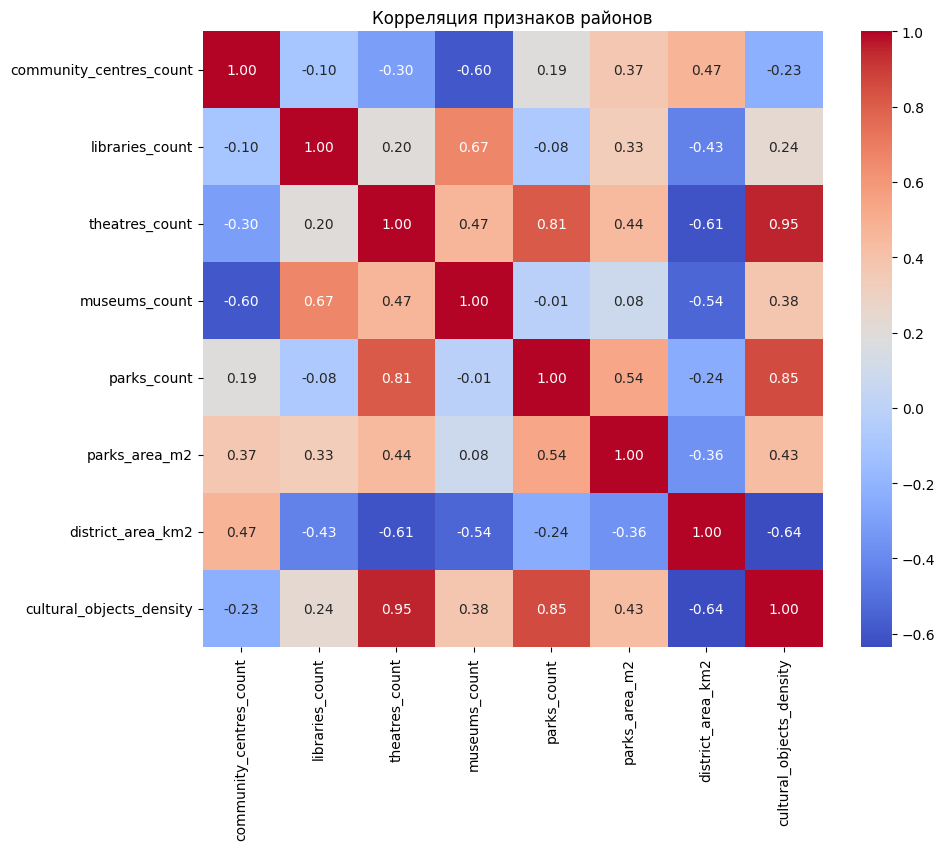

In [ ]:
district_corr = city_districts[district_feature_columns].corr()

plt.figure(figsize=(10,8))
sns.heatmap(district_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция признаков районов")
plt.show()

Наиболее сильная положительная корреляция наблюдается между количеством театров и плотностью культурных объектов (r ≈ 0.95), что указывает на то, что театры, как правило, располагаются в районах с высокой концентрацией культурной инфраструктуры в целом. Аналогичная связь прослеживается между количеством парков и плотностью объектов (r ≈ 0.85), что свидетельствует о том, что районы с развитой рекреационной средой часто обладают и более насыщенной культурной инфраструктурой.

Также заметна положительная корреляция между количеством театров и парков (r ≈ 0.81), что может отражать общую ориентацию отдельных районов на общественно-культурные функции и досуг населения. Площадь парков умеренно коррелирует как с количеством парков, так и с числом культурных объектов, что является ожидаемым результатом: крупные рекреационные зоны чаще встречаются в районах с развитой общественной инфраструктурой.

Отрицательные корреляции наблюдаются между площадью района и плотностью культурных объектов (r ≈ −0.64), а также между площадью района и количеством отдельных типов инфраструктуры. Это указывает на то, что более крупные по площади районы, как правило, имеют меньшую концентрацию культурных объектов, что характерно для менее плотно застроенных территорий.

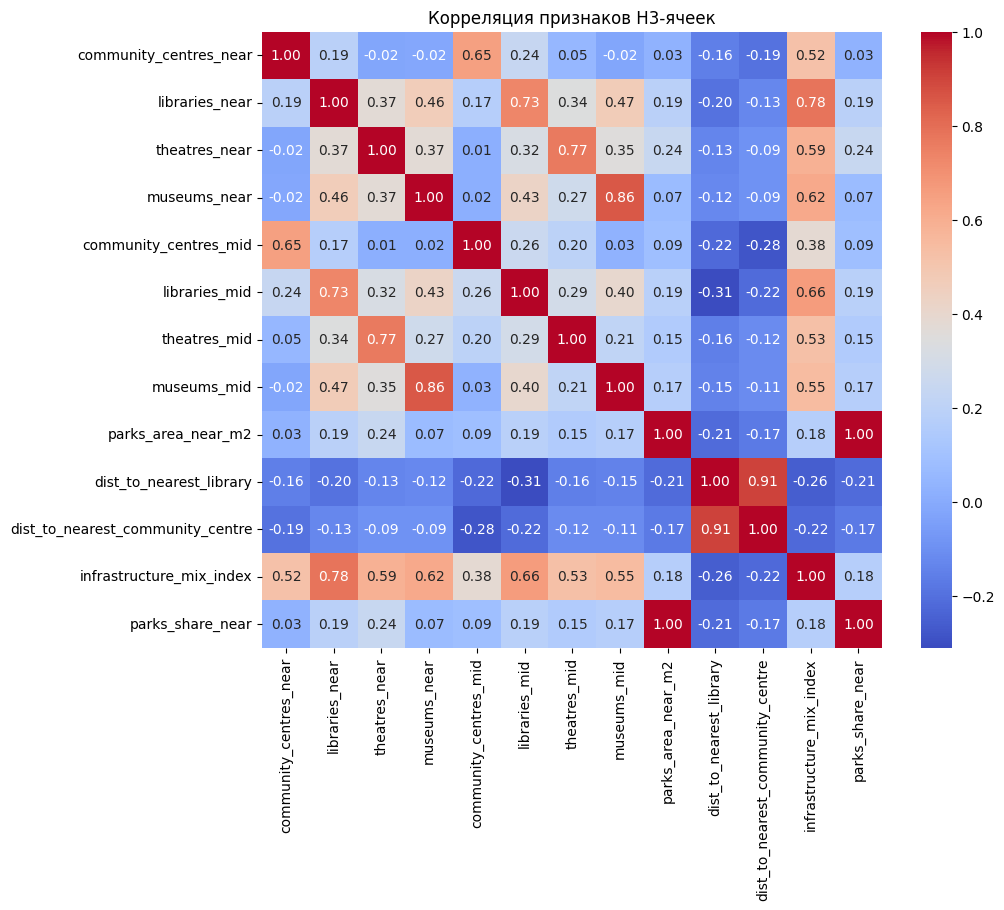

In [ ]:
h3_corr = h3_cells[h3_feature_columns].corr()

plt.figure(figsize=(10,8))
sns.heatmap(h3_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция признаков H3‑ячеек")
plt.show()

В первую очередь выделяются сильные положительные корреляции между показателями количества объектов в ближнем и среднем радиусах. Так, количество библиотек в ближнем радиусе тесно связано с количеством библиотек в среднем радиусе (r ≈ 0.73), а аналогичная зависимость наблюдается для театров и музеев. Это отражает пространственную концентрацию инфраструктуры: если объект присутствует в шаговой доступности, то, как правило, и в расширенной зоне доступности также находятся объекты того же типа.

Индекс смешанности инфраструктуры демонстрирует устойчивые положительные корреляции с большинством количественных показателей, особенно с количеством библиотек и музеев (r ≈ 0.6–0.8). Это подтверждает корректность его интерпретации: ячейки, в которых присутствует больше различных типов объектов, действительно характеризуются более насыщенной и разнообразной инфраструктурной средой.

Показатели, связанные с зелёными зонами, в частности площадь парков и их доля в ближнем радиусе, имеют слабые или умеренные корреляции с культурными объектами. Это говорит о том, что наличие парков не всегда напрямую связано с концентрацией культурной инфраструктуры и может формироваться по иным градостроительным причинам.

In [ ]:
city_districts[district_feature_columns].isna().sum()

,0
community_centres_count,0
libraries_count,0
theatres_count,0
museums_count,0
parks_count,0
parks_area_m2,0
district_area_km2,0
cultural_objects_density,0


In [ ]:
h3_cells[h3_feature_columns].isna().sum()

,0
community_centres_near,0
libraries_near,0
theatres_near,0
museums_near,0
community_centres_mid,0
libraries_mid,0
theatres_mid,0
museums_mid,0
parks_area_near_m2,0
dist_to_nearest_library,0


В рамках предыдущих этапов все пропущенные значения были заменены на нулевые, поэтому пропусков в итоговых таблицах не обнаружено.

In [ ]:
q1 = h3_cells[h3_feature_columns].quantile(0.25)
q3 = h3_cells[h3_feature_columns].quantile(0.75)
iqr = q3 - q1

outliers_mask = (
    (h3_cells[h3_feature_columns] < (q1 - 1.5 * iqr)) |
    (h3_cells[h3_feature_columns] > (q3 + 1.5 * iqr))
)

outliers_mask.sum()

,0
community_centres_near,14
libraries_near,13
theatres_near,8
museums_near,7
community_centres_mid,33
libraries_mid,35
theatres_mid,12
museums_mid,13
parks_area_near_m2,95
dist_to_nearest_library,19


В данном исследовании выбросы не удаляются, поскольку они отражают реальные городские особенности, такие как крупные парковые зоны, центральные районы с высокой концентрацией объектов.

Для сглаживания влияния выбросов на последующие расчёты применяется логарифмическое преобразование к отдельным признакам.

In [ ]:
h3_cells["parks_area_near_log"] = np.log1p(
    h3_cells["parks_area_near_m2"]
)

h3_cells["dist_to_library_log"] = np.log1p(
    h3_cells["dist_to_nearest_library"]
)

h3_cells["dist_to_community_centre_log"] = np.log1p(
    h3_cells["dist_to_nearest_community_centre"]
)

In [ ]:
h3_cells

,h3_index,geometry,h3_id,centroid,community_centres_near,libraries_near,theatres_near,museums_near,parks_near,community_centres_mid,...,museums_mid,parks_mid,parks_area_near_m2,dist_to_nearest_library,dist_to_nearest_community_centre,infrastructure_mix_index,parks_share_near,parks_area_near_log,dist_to_library_log,dist_to_community_centre_log
0,882d440c3dfffff,"POLYGON ((4421529.798 5970780.662, 4421925.255...",0,POINT (4422274.428 5970791.554),0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,7182.929100,8453.885106,0,0.0,0.0,8.879602,9.042500
1,882d44011bfffff,"POLYGON ((4398074.325 5971097.683, 4398470.971...",1,POINT (4398817.48 5971110.579),0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,12522.984687,12087.588023,0,0.0,0.0,9.435401,9.400017
2,882d440f55fffff,"POLYGON ((4410414.655 5969226.752, 4410810.595...",2,POINT (4411158.434 5969238.538),0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6102.837139,5930.304902,0,0.0,0.0,8.716673,8.688000
3,882d443a55fffff,"POLYGON ((4425082.22 5998584.365, 4425478.836 ...",3,POINT (4425829.597 5998595.861),0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,13300.485697,9167.076412,0,0.0,0.0,9.495631,9.123483
4,882d440e4dfffff,"POLYGON ((4406799.993 5976783.605, 4407196.477...",4,POINT (4407544.223 5976795.947),0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3406.487936,2337.440831,0,0.0,0.0,8.133731,7.757240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,882d440e4bfffff,"POLYGON ((4407843.335 5978879.021, 4408239.868...",492,POINT (4408587.822 5978891.344),0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,4108.191450,2263.042791,0,0.0,0.0,8.320982,7.724907
493,882d440c0bfffff,"POLYGON ((4419202.728 5973516.439, 4419598.434...",493,POINT (4419947.457 5973527.618),0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3667.780165,4863.175165,0,0.0,0.0,8.207615,8.489652
494,882d443b63fffff,"POLYGON ((4425540.971 5984702.615, 4425936.896...",494,POINT (4426287.118 5984713.618),0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3291.661738,1710.028593,0,0.0,0.0,8.099452,7.444850
495,882d440225fffff,"POLYGON ((4388953.605 5976469.243, 4389350.964...",495,POINT (4389696.658 5976483.092),0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,20948.713436,20180.908462,0,0.0,0.0,9.949880,9.912542


### **Часть 3. Оценка уровня доступности и типология территорий**

1. **Разработка интегрального индекса доступности**

   - Выберите подмножество наиболее важных признаков (по вашему мнению) для оценки доступности:
     - отдельно для районов;
     - отдельно для H3‑ячеек.
   - Нормализуйте выбранные признаки (например, с помощью MinMaxScaler или z‑нормализации), чтобы привести их к сопоставимому масштабу.
   - Определите **веса** для каждого признака:
     - обоснуйте, почему некоторые признакы важнее других;
     - приведите словесное объяснение (например, «наличие школы в шаговой доступности важнее, чем наличие большого парка, поэтому вес признака выше»).
   - Рассчитайте интегральный **индекс доступности** для:
     - каждого административного района;
     - каждой H3‑ячейки.
   - При желании разделите индекс на составляющие:
     - индекс образовательной доступности;
     - индекс медицинской доступности;
     - индекс транспортной доступности;
     - интегральный комбинированный индекс.

> **Для административных районов**
>
> Для оценки доступности на уровне районов используются агрегированные признаки, характеризующие насыщенность культурной и общественной инфраструктуры:
> - cultural_objects_density — плотность культурных объектов
> - parks_area_m2 — суммарная площадь парков
> - community_centres_count — количество домов культуры
> - libraries_count — количество библиотек
>
> Плотность объектов рассматривается как ключевой показатель, так как она учитывает размер района. Парки и культурные учреждения дополняют оценку доступности городской среды.

In [ ]:
district_features = [
    "cultural_objects_density",
    "parks_area_m2",
    "community_centres_count",
    "libraries_count",
]

> **Для H3-ячеек**
>
> Для H3-ячеек приоритет отдаётся шаговой доступности, поэтому используются признаки ближнего радиуса, а также расстояния до ближайших объектов:
> - количество объектов культуры в ближнем радиусе;
> - индекс смешанности инфраструктуры;
> - доля парков в ближнем радиусе;
> - расстояние до ближайшей библиотеки;
> - расстояние до ближайшего дома культуры.

In [ ]:
h3_features = [
    "community_centres_near",
    "libraries_near",
    "theatres_near",
    "museums_near",
    "infrastructure_mix_index",
    "parks_share_near",
    "dist_to_nearest_library",
    "dist_to_nearest_community_centre",
]

In [ ]:
district_scaler = MinMaxScaler()

district_scaled = district_scaler.fit_transform(
    city_districts[district_features]
)

district_scaled_df = pd.DataFrame(
    district_scaled,
    columns=district_features,
    index=city_districts.index,
)

Для расстояний используется обратная интерпретация: чем меньше расстояние, тем выше доступность. Поэтому перед нормализацией берётся обратное значение.

In [ ]:
h3_cells = h3_cells.copy()

h3_cells["inv_dist_library"] = 1 / (1 + h3_cells["dist_to_nearest_library"])
h3_cells["inv_dist_community"] = (
    1 / (1 + h3_cells["dist_to_nearest_community_centre"])
)

h3_features_scaled = [
    "community_centres_near",
    "libraries_near",
    "theatres_near",
    "museums_near",
    "infrastructure_mix_index",
    "parks_share_near",
    "inv_dist_library",
    "inv_dist_community",
]

h3_scaler = MinMaxScaler()

h3_scaled = h3_scaler.fit_transform(
    h3_cells[h3_features_scaled]
)

h3_scaled_df = pd.DataFrame(
    h3_scaled,
    columns=h3_features_scaled,
    index=h3_cells.index,
)


> **Веса для районов**
>
> - плотность культурных объектов - 0.40
> - площадь парков - 0.25
> - дома культуры - 0.20
> - библиотеки - 0.15
>
> Плотность имеет наибольший вес, так как отражает реальную насыщенность района. Парки и учреждения культуры усиливают качество городской среды, но играют вспомогательную роль.

In [ ]:
district_weights = {
    "cultural_objects_density": 0.40,
    "parks_area_m2": 0.25,
    "community_centres_count": 0.20,
    "libraries_count": 0.15,
}

> **Веса для H3-ячеек**
>
> - объекты в ближнем радиусе - 0.50
> - индекс смешанности - 0.20
> - доля парков - 0.10
> - близость к библиотеке - 0.10
> - близость к дому культуры - 0.10
>
> Шаговая доступность имеет приоритет, поэтому признаки ближнего радиуса получают больший вес.

In [ ]:
h3_weights = {
    "community_centres_near": 0.15,
    "libraries_near": 0.15,
    "theatres_near": 0.10,
    "museums_near": 0.10,
    "infrastructure_mix_index": 0.20,
    "parks_share_near": 0.10,
    "inv_dist_library": 0.10,
    "inv_dist_community": 0.10,
}

Расчёт интегрального индекса

In [ ]:
city_districts["district_access_index"] = 0.0

for feature, weight in district_weights.items():
    city_districts["district_access_index"] += (
        district_scaled_df[feature] * weight
    )

city_districts

,geometry,boundary,ref,admin_level,source,boat,name,name:uk,waterway,alt_name,...,district_id,community_centres_count,libraries_count,theatres_count,museums_count,parks_count,parks_area_m2,district_area_km2,cultural_objects_density,district_access_index
0,"POLYGON ((4387562.974 5979717.212, 4387629.532...",administrative,NaN,9,NaN,NaN,Советский район,Радянський район,NaN,NaN,...,0,3.0,2,0.0,0.0,17,5.454862e+05,188.345066,0.116807,0.177911
1,"POLYGON ((4402085.203 5969289.194, 4402133.794...",administrative,NaN,9,NaN,NaN,Железнодорожный район,Залізничний район,NaN,NaN,...,1,3.0,2,0.0,2.0,9,2.895872e+05,152.154685,0.105156,0.150000
2,"POLYGON ((4414214.553 5982435.054, 4414312.002...",administrative,NaN,9,NaN,NaN,Ленинский район,Ленінський район,NaN,NaN,...,2,0.0,3,2.0,2.0,22,4.664016e+05,28.655629,1.012018,0.341493
3,"POLYGON ((4409999.685 5983895.98, 4410547.677 ...",administrative,NaN,9,NaN,NaN,Октябрьский район,Жовтневий район,NaN,NaN,...,3,6.0,4,0.0,1.0,18,2.611609e+06,96.580067,0.300269,0.625367
4,"POLYGON ((4420778.217 5982084.299, 4421342.306...",administrative,NaN,9,NaN,NaN,Кировский район,Кіровський район,NaN,NaN,...,4,0.0,4,4.0,4.0,31,2.114490e+06,41.965193,1.024659,0.555827
5,"POLYGON ((4423038.403 5981980.092, 4423735.686...",administrative,NaN,9,NaN,NaN,Пролетарский район,Пролетарський район,NaN,NaN,...,5,4.0,2,5.0,1.0,124,2.845416e+06,78.926477,1.723123,0.833333
6,"POLYGON ((4417545.031 5989806.76, 4417562.542 ...",administrative,NaN,9,NaN,NaN,Ворошиловский район,Ворошиловський район,NaN,NaN,...,6,3.0,1,1.0,0.0,18,1.183271e+06,88.410782,0.260149,0.225734
7,"POLYGON ((4422379.036 5989474.449, 4422454.51 ...",administrative,NaN,9,NaN,NaN,Первомайский район,Першотравневий район,NaN,NaN,...,7,2.0,2,0.0,1.0,10,2.235354e+06,96.907115,0.154787,0.319263


In [ ]:
h3_cells["h3_access_index"] = 0.0

for feature, weight in h3_weights.items():
    h3_cells["h3_access_index"] += (
        h3_scaled_df[feature] * weight
    )

h3_cells

,h3_index,geometry,h3_id,centroid,community_centres_near,libraries_near,theatres_near,museums_near,parks_near,community_centres_mid,...,dist_to_nearest_library,dist_to_nearest_community_centre,infrastructure_mix_index,parks_share_near,parks_area_near_log,dist_to_library_log,dist_to_community_centre_log,inv_dist_library,inv_dist_community,h3_access_index
0,882d440c3dfffff,"POLYGON ((4421529.798 5970780.662, 4421925.255...",0,POINT (4422274.428 5970791.554),0.0,0.0,0.0,0.0,0.0,0.0,...,7182.929100,8453.885106,0,0.0,0.0,8.879602,9.042500,0.000139,0.000118,0.001938
1,882d44011bfffff,"POLYGON ((4398074.325 5971097.683, 4398470.971...",1,POINT (4398817.48 5971110.579),0.0,0.0,0.0,0.0,0.0,0.0,...,12522.984687,12087.588023,0,0.0,0.0,9.435401,9.400017,0.000080,0.000083,0.000883
2,882d440f55fffff,"POLYGON ((4410414.655 5969226.752, 4410810.595...",2,POINT (4411158.434 5969238.538),0.0,0.0,0.0,0.0,0.0,0.0,...,6102.837139,5930.304902,0,0.0,0.0,8.716673,8.688000,0.000164,0.000169,0.002858
3,882d443a55fffff,"POLYGON ((4425082.22 5998584.365, 4425478.836 ...",3,POINT (4425829.597 5998595.861),0.0,0.0,0.0,0.0,0.0,0.0,...,13300.485697,9167.076412,0,0.0,0.0,9.495631,9.123483,0.000075,0.000109,0.001196
4,882d440e4dfffff,"POLYGON ((4406799.993 5976783.605, 4407196.477...",4,POINT (4407544.223 5976795.947),0.0,0.0,0.0,0.0,0.0,0.0,...,3406.487936,2337.440831,0,0.0,0.0,8.133731,7.757240,0.000293,0.000428,0.007622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,882d440e4bfffff,"POLYGON ((4407843.335 5978879.021, 4408239.868...",492,POINT (4408587.822 5978891.344),0.0,0.0,0.0,0.0,0.0,0.0,...,4108.191450,2263.042791,0,0.0,0.0,8.320982,7.724907,0.000243,0.000442,0.007330
493,882d440c0bfffff,"POLYGON ((4419202.728 5973516.439, 4419598.434...",493,POINT (4419947.457 5973527.618),0.0,0.0,0.0,0.0,0.0,0.0,...,3667.780165,4863.175165,0,0.0,0.0,8.207615,8.489652,0.000273,0.000206,0.004409
494,882d443b63fffff,"POLYGON ((4425540.971 5984702.615, 4425936.896...",494,POINT (4426287.118 5984713.618),0.0,0.0,0.0,0.0,0.0,0.0,...,3291.661738,1710.028593,0,0.0,0.0,8.099452,7.444850,0.000304,0.000584,0.009848
495,882d440225fffff,"POLYGON ((4388953.605 5976469.243, 4389350.964...",495,POINT (4389696.658 5976483.092),0.0,0.0,0.0,0.0,0.0,0.0,...,20948.713436,20180.908462,0,0.0,0.0,9.949880,9.912542,0.000048,0.000050,0.000124


Индекс принимает значения в диапазоне от 0 до 1 и отражает относительный уровень доступности культурной и общественной инфраструктуры.

### **Часть 4. Визуализация результатов и формирование выводов**

1. **Тепловая карта по административным районам**

   - Переведите слой районов обратно в систему координат `EPSG:4326` для отображения.
   - С помощью `leafmap` или `folium` постройте **хороплет‑карту (choropleth)**:
     - заливка районов по значению интегрального индекса доступности;
     - выберите подходящую цветовую схему (например, `Blues`, `Greens`, `YlGnBu`);
     - добавьте легенду с подписью (например, «Индекс доступности социальной инфраструктуры»).
   - При необходимости создайте несколько слоёв:
     - отдельные карты для разных компонент индекса (образование/медицина/транспорт).

In [ ]:
districts_wgs84 = city_districts.to_crs(epsg=4326)

In [ ]:
map = leafmap.Map(
    center=[47.222109, 39.718813],
    zoom=11
)

map.add_data(
    districts_wgs84,
    column="district_access_index",
    cmap="YlGnBu",
    legend_title="Индекс доступности социальной инфраструктуры",
    layer_name="Тепловая карта районов",
    style={
        "stroke": True,
        "weight": 1,
        "fillOpacity": 0.7,
        "color": "black",
    },
)

map

Map(center=[47.222109, 39.718813], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title',…

2. **Тепловая карта по H3‑сетки**

   - Переведите H3‑ячейки в CRS `EPSG:4326`.
   - Постройте отдельную карту, где:
     - каждая H3‑ячейка окрашена в соответствии с индексом доступности или номером кластера;
     - используйте хорошую цветовую палитру (например, `OrRd`, `RdYlGn`);
     - настройте прозрачность заливки, чтобы можно было видеть подложку карты.
   - Добавьте всплывающие подсказки (popup/tooltip) с основными показателями для выбранной ячейки:
     - значение индекса;
     - количество объектов;
     - расстояние до ближайшего объекта и т.п.

In [ ]:
h3_cells_wgs84 = (
    h3_cells
    .to_crs(epsg=4326)
    .drop(columns=["centroid"])
)

In [ ]:
m_h3 = leafmap.Map(
    center=[47.222109, 39.718813],
    zoom=11
)

m_h3.add_data(
    h3_cells_wgs84,
    column="h3_access_index",
    cmap="OrRd",
    legend_title="H3 индекс доступности социальной инфраструктуры",
    layer_name="H3 тепловая карта",
    style={
        "stroke": False,
        "weight": 0,
        "fillOpacity": 0.65,
    },
)

m_h3


Map(center=[47.222109, 39.718813], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title',…

3. **Выделение зон с высокой и низкой доступностью**

   - Определите **пороги** (например, по квартилям или по значениям индекса), чтобы выделить:
     - зоны с высокой доступностью;
     - зоны с низкой доступностью.
   - На карте H3‑ячеек:
     - визуально выделите несколько локальных «кластеров» высокой и низкой доступности;
     - подпишите или сохраните их идентификаторы (H3‑индекс, координаты).

In [ ]:
h3_cells_vis = (
    h3_cells
    .to_crs(epsg=4326)
    .drop(columns=["centroid"])
)

In [ ]:
q1 = h3_cells_vis["h3_access_index"].quantile(0.25)
q3 = h3_cells_vis["h3_access_index"].quantile(0.75)

h3_cells_vis["accessibility_zone"] = "medium"
h3_cells_vis.loc[
    h3_cells_vis["h3_access_index"] <= q1,
    "accessibility_zone"
] = "low"

h3_cells_vis.loc[
    h3_cells_vis["h3_access_index"] >= q3,
    "accessibility_zone"
] = "high"

h3_cells_vis["accessibility_zone"].value_counts()


,count
accessibility_zone,
medium,247
low,125
high,125


In [ ]:
high_cells = h3_cells_vis[
    h3_cells_vis["accessibility_zone"] == "high"
]

low_cells = h3_cells_vis[
    h3_cells_vis["accessibility_zone"] == "low"
]

medium_cells = h3_cells_vis[
    h3_cells_vis["accessibility_zone"] == "medium"
]


In [ ]:
high_cells[["h3_index"]].to_csv(
    "high_accessibility_cells.csv",
    index=False
)

low_cells[["h3_index"]].to_csv(
    "low_accessibility_cells.csv",
    index=False
)


In [ ]:
m_zones = leafmap.Map(
    center=[47.222109, 39.718813],
    zoom=11
)

m_zones.add_gdf(
    high_cells,
    layer_name="Высокая доступность",
    style={
        "fillColor": "green",
        "color": "black",
        "weight": 0.5,
        "fillOpacity": 0.7,
    },
)

m_zones.add_gdf(
    low_cells,
    layer_name="Низкая доступность",
    style={
        "fillColor": "red",
        "color": "black",
        "weight": 0.5,
        "fillOpacity": 0.7,
    },
)

m_zones.add_gdf(
    medium_cells,
    layer_name="Средняя доступность",
    style={
        "fillColor": "yellow",
        "color": "black",
        "weight": 0.3,
        "fillOpacity": 0.4,
    },
)

m_zones.add_layer_control()
m_zones


Map(center=[47.222109, 39.718813], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title',…

4. **Интерпретация результатов и рекомендации**

   - Подготовьте **краткий текстовый анализ**, в котором:
     - опишите общую картину по району/городу:
       - какие части города наиболее обеспечены социальной инфраструктурой;
       - какие — недообеспечены;
     - проанализируйте различия между:
       - оценкой по районам;
       - и оценкой по H3‑ячеек (более детальный уровень).
   - Сформулируйте **5–7 практических рекомендаций**, например:
     - где целесообразно планировать строительство новых школ/детсадов/поликлиник;
     - какие районы требуют улучшения транспортной доступности;
     - какие зоны уже хорошо обеспечены и могут служить «бенчмарками» для планирования других территорий.
   - Укажите **проблемы исследования**:
     - неполнота данных OSM;
     - отсутствие данных о численности населения;
     - грубые допущения при выборе радиусов и весов.

---

> ## **Интерпретация результатов и рекомендации**
>### **Общая картина обеспеченности социальной инфраструктурой**
>
>Проведённый пространственный анализ показал, что обеспеченность социальной и культурной инфраструктурой на территории города распределена неравномерно. Наиболее высокие значения доступности характерны для центральных и исторически сформировавшихся районов города, где сосредоточено большое количество культурных объектов, общественных пространств и парков. Эти территории отличаются высокой плотностью инфраструктуры и меньшими расстояниями до ключевых объектов.
>
>Наименее обеспеченными оказываются периферийные и преимущественно жилые районы, в которых количество объектов социальной инфраструктуры ограничено, а расстояния до ближайших культурных и общественных учреждений значительно больше. Для таких территорий характерны зоны с низкими значениями индекса доступности, что указывает на потенциальный дефицит инфраструктуры.
>
>### **Сравнение оценки по районам и по H3-ячейкам**
>
>Анализ на уровне административных районов позволяет получить обобщённую картину доступности, однако сглаживает локальные различия внутри районов. В рамках одного района могут одновременно присутствовать как хорошо обеспеченные участки, так и зоны с низкой доступностью.
>
>Использование гексагональной H3-сетки позволило выявить более детальную пространственную структуру. На уровне H3-ячеек чётко прослеживаются локальные кластеры высокой и низкой доступности, которые не всегда совпадают с границами административных районов. Это показывает, что даже в районах с высокой средней оценкой могут существовать отдельные проблемные зоны, требующие внимания при городском планировании.
>
>### **Практические рекомендации**
>
>На основе полученных результатов можно сформулировать следующие рекомендации:
>- В зонах с низкой доступностью, выявленных на уровне H3-ячеек, целесообразно рассмотреть размещение новых объектов социальной и культурной инфраструктуры, в первую очередь общественных центров и библиотек.
>- Территории с высокой доступностью могут рассматриваться как опорные зоны для дальнейшего развития городской среды и использоваться в качестве примеров успешной концентрации инфраструктуры.
>- При планировании новых жилых кварталов необходимо учитывать выявленные радиусы доступности и стремиться к равномерному размещению объектов социальной инфраструктуры.
>- Зоны со средней доступностью требуют точечного вмешательства: добавления отдельных объектов или улучшения пешеходной доступности без масштабного строительства.
>
>### **Ограничения и проблемы исследования**
>
>При интерпретации результатов важно учитывать ряд ограничений. Данные OpenStreetMap могут быть неполными или содержать неточности, так как они формируются пользователями. В исследовании не использовались сведения о численности и плотности населения, поэтому невозможно напрямую оценить обеспеченность инфраструктурой на душу населения. Выбор радиусов доступности и весов признаков основан на экспертных допущениях и может влиять на итоговые значения индекса. При этом интегральный индекс отражает относительную, а не абсолютную доступность и предназначен прежде всего для сравнительного анализа территорий.
>
>### **Итоговый вывод**
>
>Использование гексагональной H3-сетки в сочетании с анализом на уровне административных районов позволило получить комплексное представление о пространственной доступности социальной инфраструктуры. Такой подход сочетает обобщённую оценку и детальный локальный анализ, что делает его удобным инструментом для задач городского планирования и пространственного анализа.